In [1]:
# Load dataset
import pandas as pd

df = pd.read_csv('./BTC-Daily.csv')

# Remove duplicate rows
df = df.drop_duplicates()

# Part 1: Data Exploration and Preparetion

In [2]:
df.describe()

,unix,open,high,low,close,Volume BTC,Volume USD
count,2.651000e+03,2651.000000,2651.000000,2651.000000,2651.000000,2.651000e+03,2.651000e+03
mean,1.531613e+09,11693.189332,12038.562912,11296.539461,11709.326213,1.330041e+07,6.099369e+07
std,6.613247e+07,16272.554746,16739.237000,15718.297511,16282.908704,4.715366e+07,1.072838e+08
min,1.417133e+09,162.000000,212.840000,152.400000,162.000000,0.000000e+00,0.000000e+00
25%,1.474373e+09,654.680000,664.460000,640.050000,654.370000,5.357883e+03,9.516170e+03
50%,1.531613e+09,6408.950000,6540.000000,6312.000000,6407.770000,1.503310e+04,2.288982e+07
75%,1.588853e+09,10708.620000,10956.240000,10303.755000,10726.425000,3.435336e+06,8.018383e+07
max,1.646093e+09,67547.490000,69000.000000,66250.000000,67559.000000,7.723295e+08,1.446125e+09


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2651 entries, 0 to 2650
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   unix        2651 non-null   int64  
 1   date        2651 non-null   object 
 2   symbol      2651 non-null   object 
 3   open        2651 non-null   float64
 4   high        2651 non-null   float64
 5   low         2651 non-null   float64
 6   close       2651 non-null   float64
 7   Volume BTC  2651 non-null   float64
 8   Volume USD  2651 non-null   float64
dtypes: float64(6), int64(1), object(2)
memory usage: 186.5+ KB


In [4]:
# Range of dates covered
df['date'] = pd.to_datetime(df['date'])
date_range = str(df['date'].dt.date.min()) + ' to ' + str(df['date'].dt.date.max())
print(date_range)

2014-11-28 to 2022-03-01


In [5]:
# statistic of closing price
df['close'].describe()

,close
count,2651.000000
mean,11709.326213
std,16282.908704
min,162.000000
25%,654.370000
50%,6407.770000
75%,10726.425000
max,67559.000000


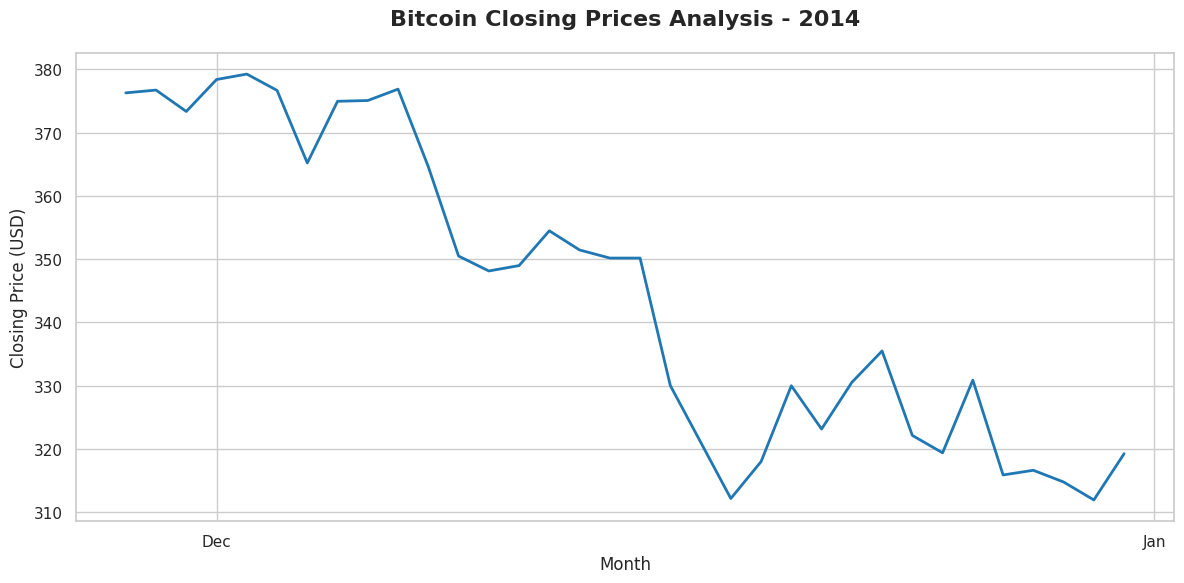

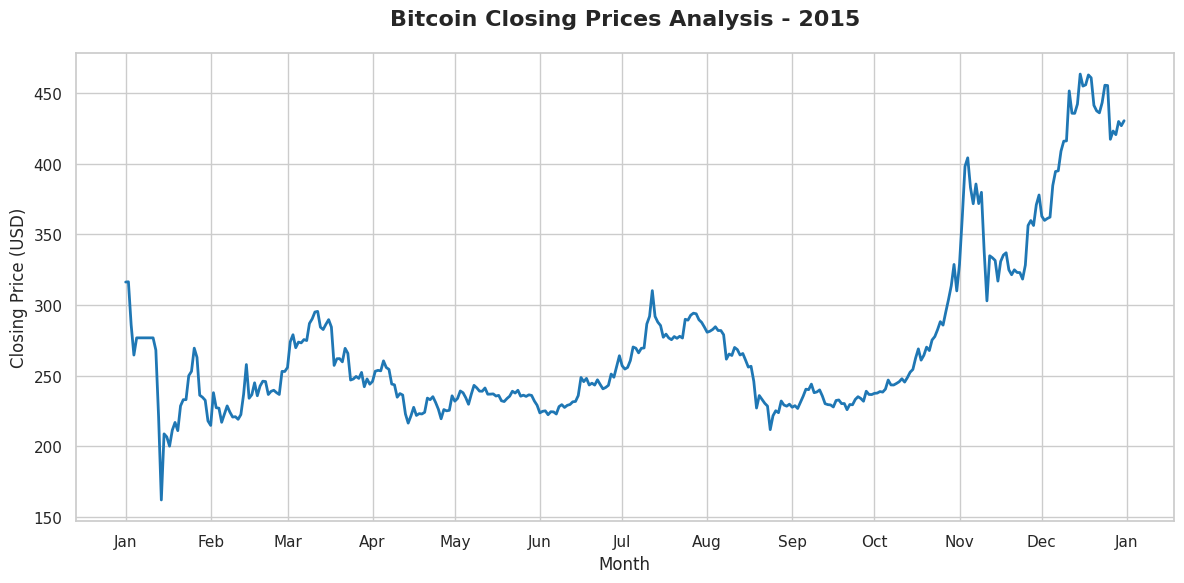

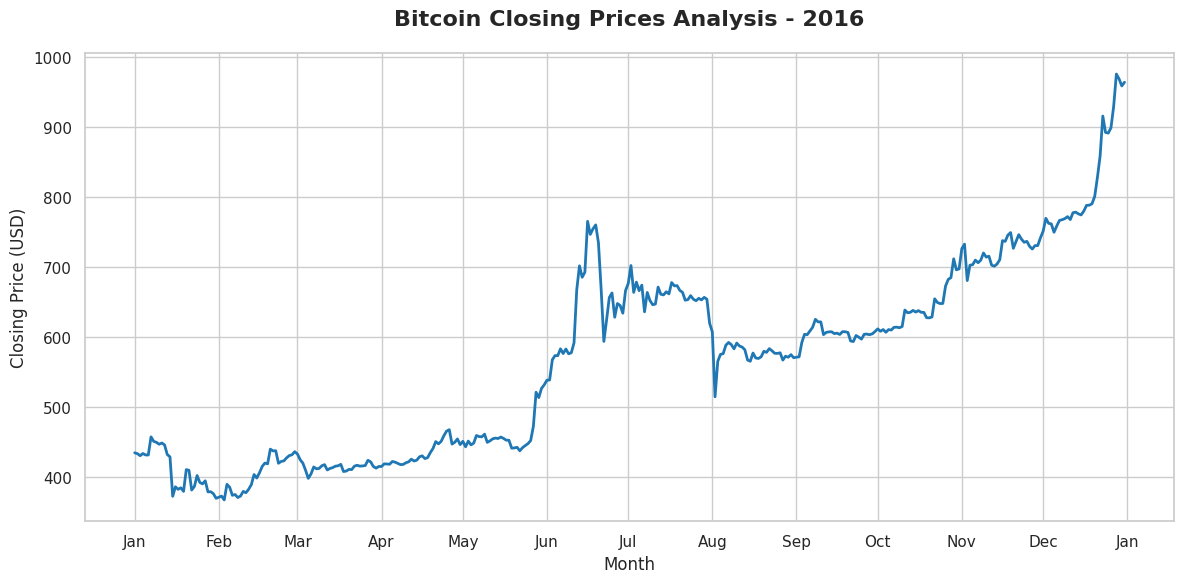

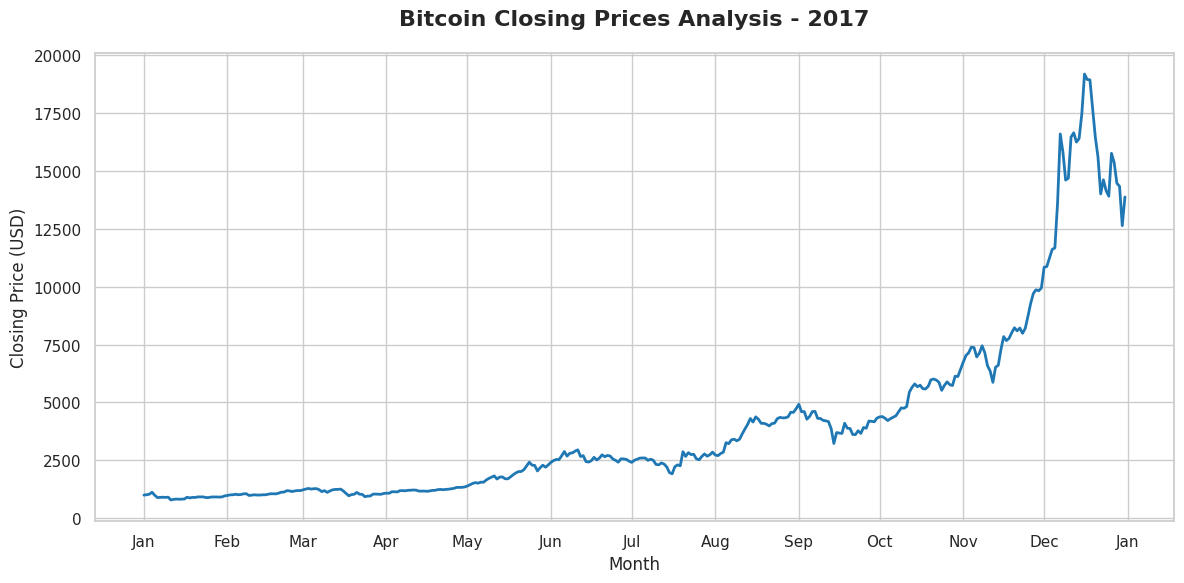

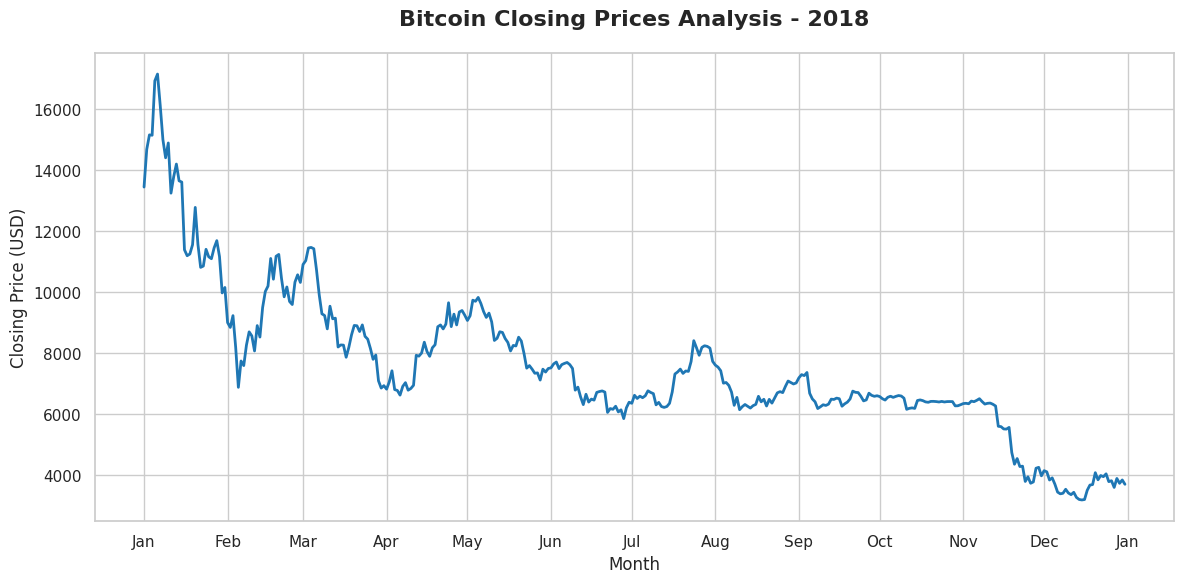

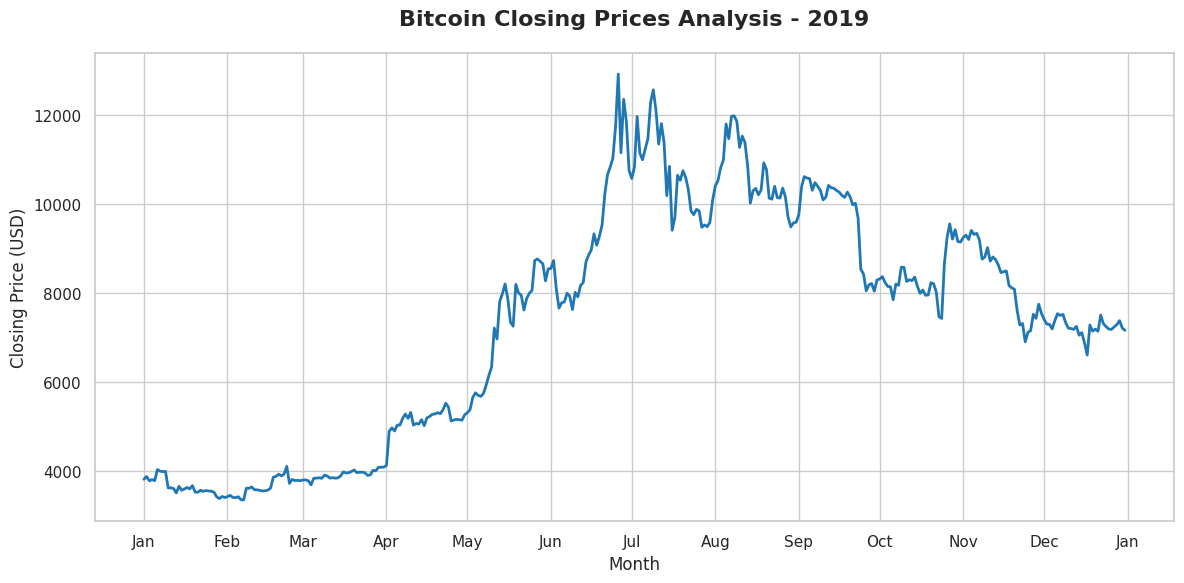

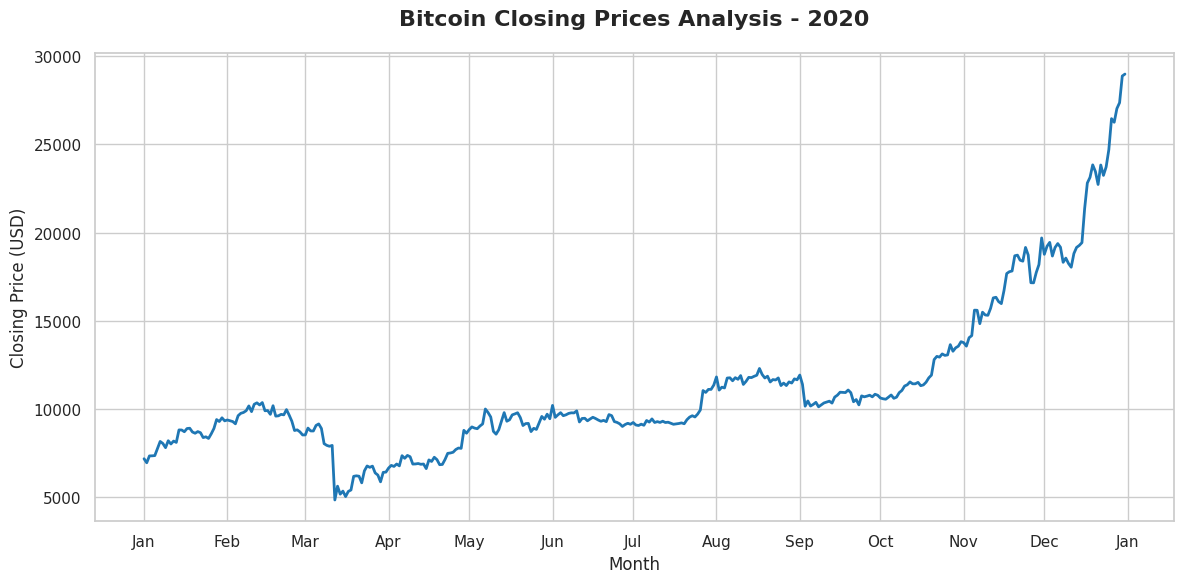

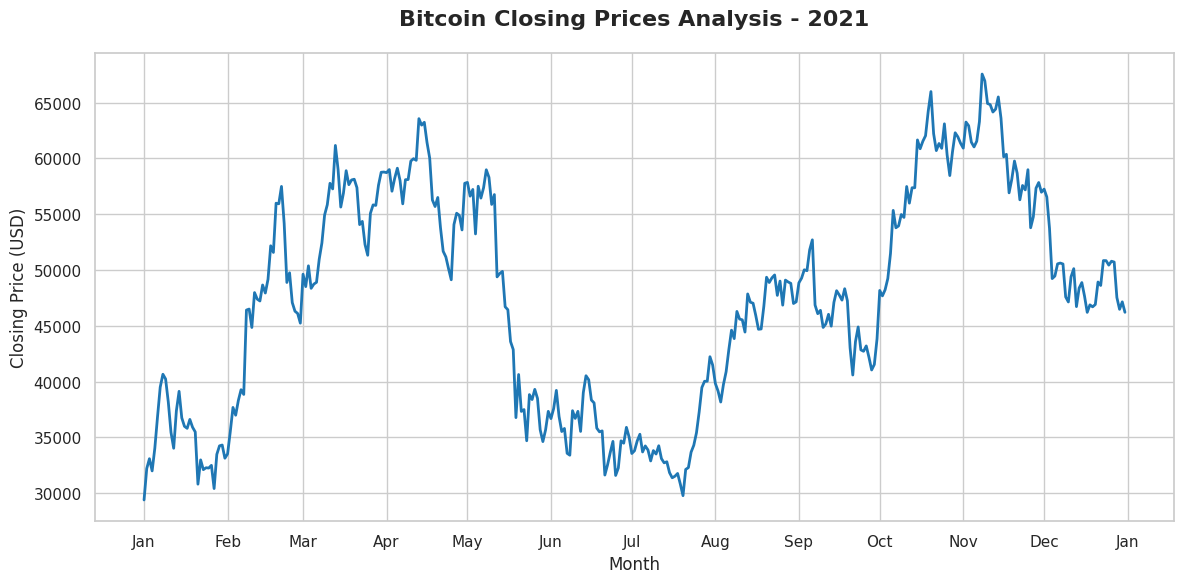

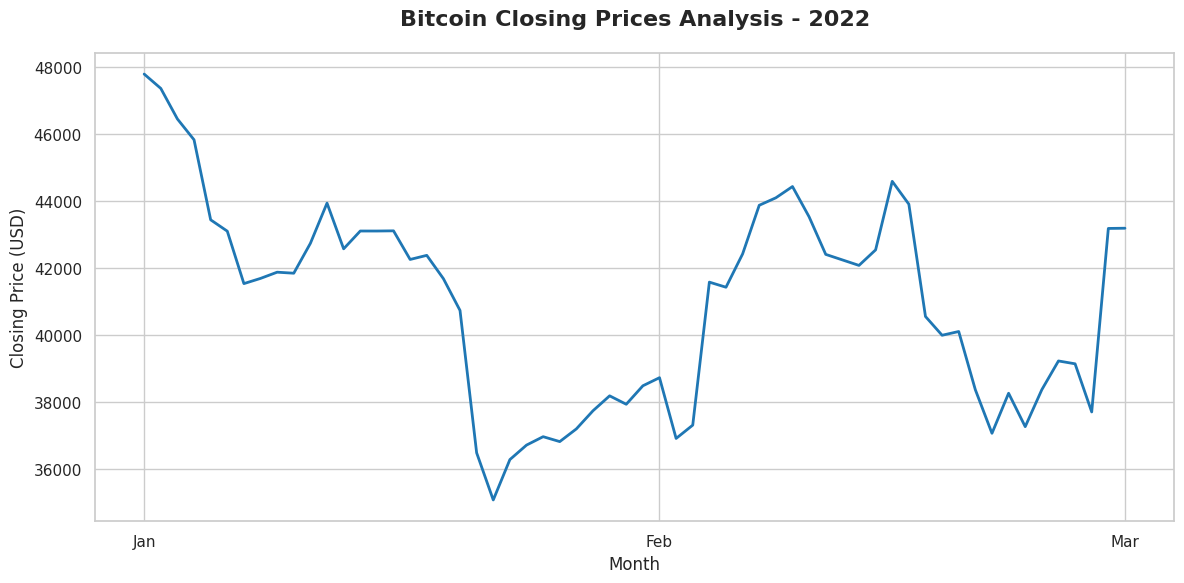

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Set a more beautiful style
sns.set_theme(style="whitegrid")

# Extract date parts
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

unique_years = sorted(df['year'].unique())

for year in unique_years:
    # Create a full year date range
    dates = pd.date_range(start=f'{year}-01-01', end=f'{year}-12-31', freq='D')
    year_month_day = pd.DataFrame({'date': dates})
    year_month_day['year'] = year_month_day['date'].dt.year
    year_month_day['month'] = year_month_day['date'].dt.month
    year_month_day['day'] = year_month_day['date'].dt.day

    # Merge to ensure continuity in the plot
    merged_data = pd.merge(year_month_day, df, on=['year', 'month', 'day'], how='left')

    # Visualization
    plt.figure(figsize=(12, 6))
    plt.plot(merged_data['date_x'], merged_data['close'], color='#1f77b4', linewidth=2)

    # Formatting titles and labels
    plt.title(f'Bitcoin Closing Prices Analysis - {year}', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Closing Price (USD)', fontsize=12)

    # Better date formatting on X-axis
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

    plt.tight_layout()
    plt.show()

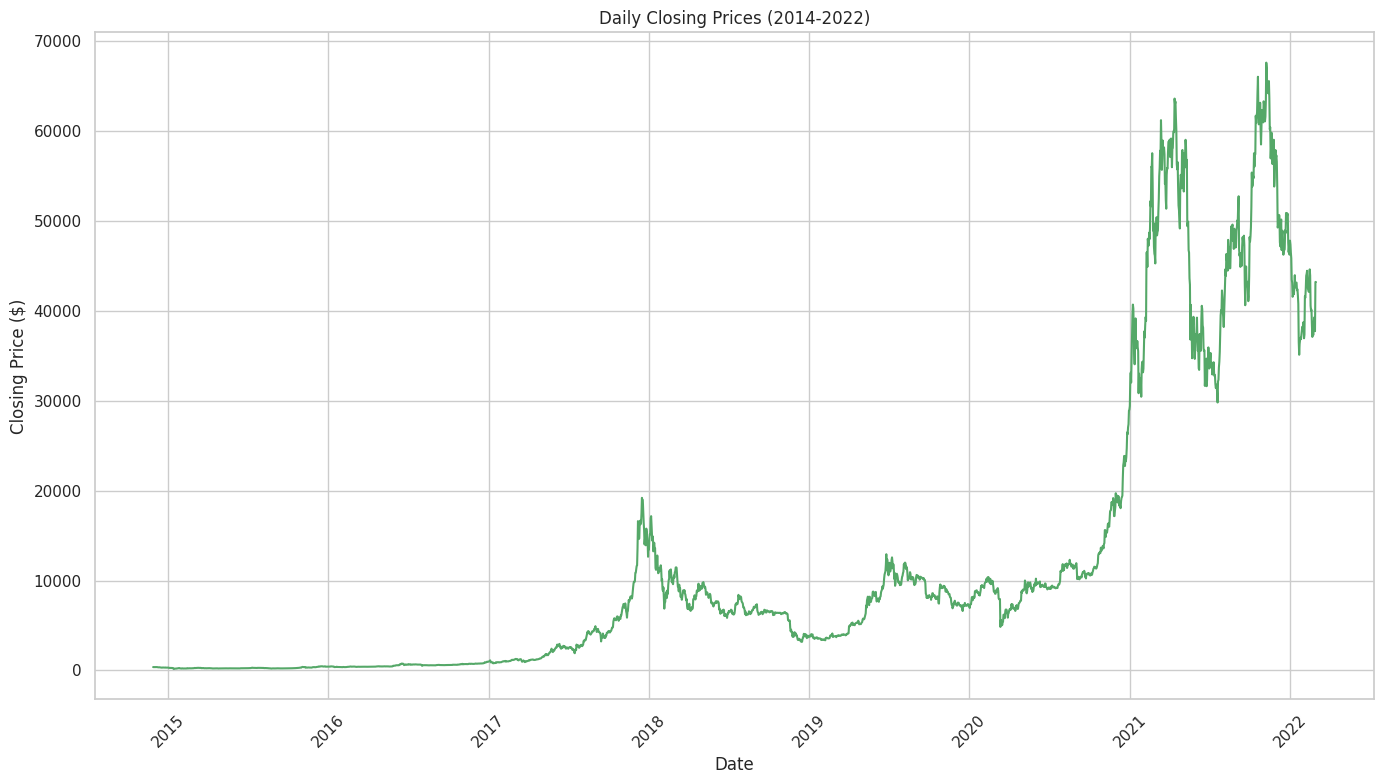

In [7]:
plt.figure(figsize=(14, 8))
plt.plot(df['date'], df['close'], linestyle='-', color='g')
plt.title('Daily Closing Prices (2014-2022)')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
!pip install mplfinance

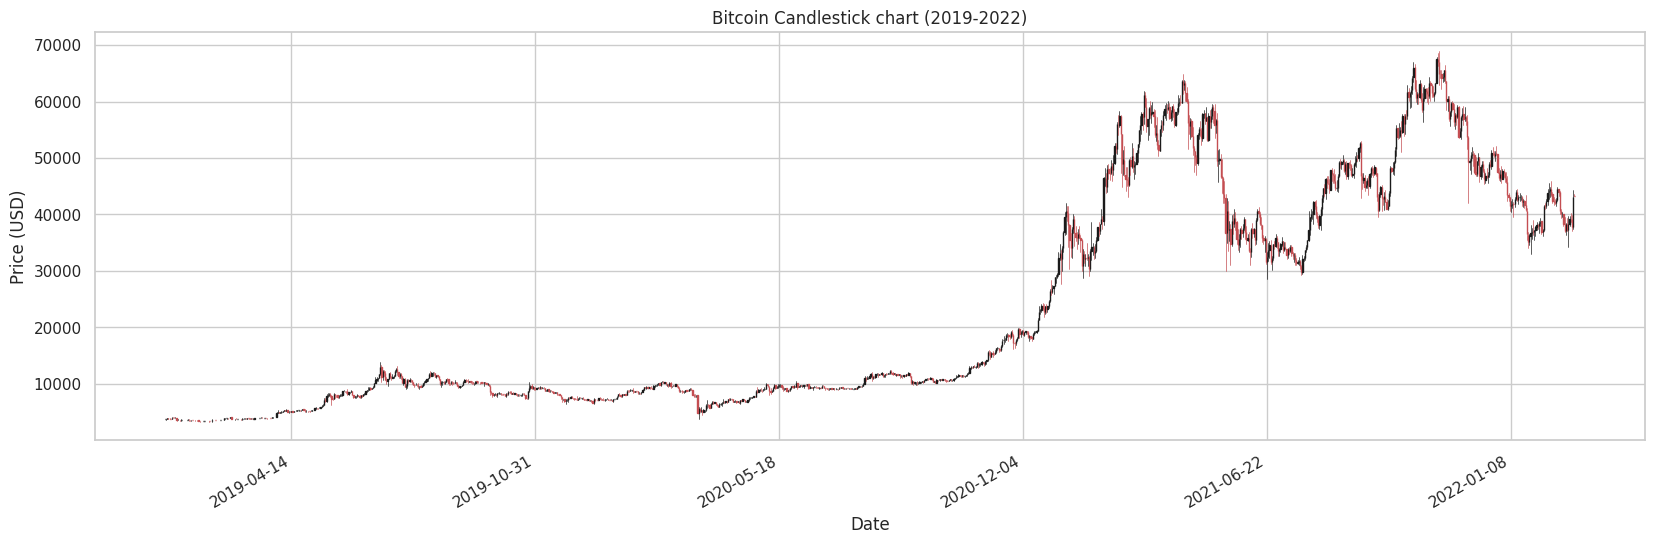

In [9]:
# Candelstick chart
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mplfinance.original_flavor import candlestick_ohlc
import datetime

# Filter date for 2019-2022
df_filtered = df[(df['date'] >= '2019-01-01') & (df['date'] <= '2022-12-31')].copy()

# Convert date to matplotlib format
df_filtered['date'] = df_filtered['date'].map(mdates.date2num)

# Create the candlestick chart
fig, ax = plt.subplots(figsize=(20, 6))

candlestick_ohlc(ax, df_filtered[['date', 'open', 'high', 'low', 'close']].values)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()

plt.title('Bitcoin Candlestick chart (2019-2022)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)

# save the plot as a PDF
plt.savefig('bitcoin_candlestick_2019-2022.pdf')

plt.show()

In [10]:
# Checking for Null Values in dataset
df.isnull().sum()

#As can be seen there are no NULL values in the data

,0
unix,0
date,0
symbol,0
open,0
high,0
low,0
close,0
Volume BTC,0
Volume USD,0
year,0


In [29]:
# Standardizing the prices for Modeling and plotting them
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()

df["Standardized_Close_Prices"] = scalar.fit_transform(df["close"].values.reshape(-1,1))
df["Standardized_Open_Prices"] = scalar.fit_transform(df["open"].values.reshape(-1,1))
df["Standardized_High_Prices"] = scalar.fit_transform(df["high"].values.reshape(-1,1))
df["Standardized_Low_Prices"] = scalar.fit_transform(df["low"].values.reshape(-1,1))

# Part 2: Building Forecasting Models

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error as mae
import numpy as np

In [31]:
#Converting Date to numerical form

df['date_str'] = df['date'].dt.strftime('%Y%m%d%H%M%S')

# Convert the string date to a numerical value
df['NumericalDate'] = pd.to_numeric(df['date_str'])
df["Standardized_Date"] = scalar.fit_transform(df[["NumericalDate"]])

# Drop the intermediate 'date_str' column if not needed
df.drop(columns=['date_str'], inplace=True)

In [32]:
def predict(X, w, b):
  return X.dot(w) + b

def gradient(y_hat, y, x):
    loss = y_hat-y
    dw = x.T.dot(loss)/len(y)
    db = np.sum(loss)/len(y)
    cost = np.sum(loss**2)/(2*len(y))
    return (dw,db, cost)

def update_weight(w,b,lr,dw,db):
    w_new = w - lr*dw
    b_new = b - lr*db
    return (w_new, b_new)

In [33]:
def linear_regression_vectorized(X, y, learning_rate=0.01, num_iterations=200):
  """
  Args:
    X: Feature matrix (numpy array).
    y: Target variable (numpy array).
    learning_rate: Learning rate for gradient descent.
    num_iterations: Number of iterations for gradient descent.

  Returns:
    w: Optimal weight vector.
    b: Optimal bias term.
  """
  n_samples, n_features = X.shape
  w = np.zeros(n_features)  # Initialize weights
  b = 0  # Initialize bias
  losses = []

  for _ in range(num_iterations):
    y_hat = predict(X, w, b)  # Make predictions
    dw, db, cost = gradient(y_hat, y, X)  # Calculate gradients
    w, b = update_weight(w, b, learning_rate, dw, db)  # Update weights and bias
    losses.append(cost)


  return w, b, losses

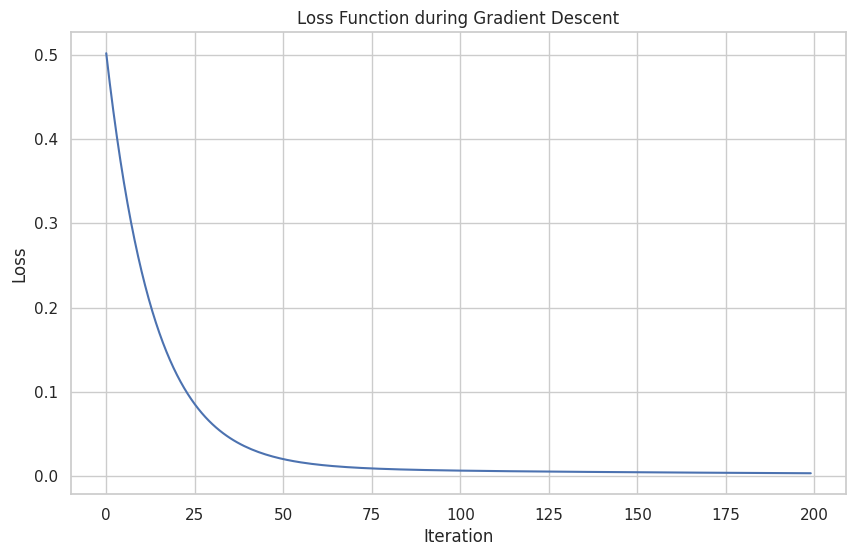

In [35]:
X = df[["Standardized_Date", "Standardized_Open_Prices", "Standardized_High_Prices", "Standardized_Low_Prices"]]
y = df["Standardized_Close_Prices"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, shuffle=True)

b = 0
w = np.zeros(X_train.shape[1])
lr = 0.01
epochs = 200

w, b, losses = linear_regression_vectorized(X_train.values, y_train.values, lr, epochs)

# Plot the loss function
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss Function during Gradient Descent')
plt.show()

In [36]:
# Evaluating Linear Regression Model
from sklearn.metrics import r2_score

# Make predictions on the test set
y_pred = predict(X_test, w, b)

# Calculate RMSE
rmse = np.sqrt(np.mean((y_pred - y_test) ** 2))

# Calculate MAE
mae = np.mean(np.abs(y_pred - y_test))

# Calculate MAPE
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100


# Calculate R-squared on training data
y_train_pred = predict(X_train, w, b)
train_accuracy = r2_score(y_train, y_train_pred)

# Calculate R-squared on testing data
test_accuracy = r2_score(y_test, y_pred)

print("Root Mean Square Error (RMSE):", round(rmse, 4))
print("Mean Absolute Error (MAE):", round(mae, 4))
print("Training Accuracy (R-squared):", round(train_accuracy, 4))
print("Testing Accuracy (R-squared):", round(test_accuracy, 4))

Root Mean Square Error (RMSE): 0.0796
Mean Absolute Error (MAE): 0.0656
Training Accuracy (R-squared): 0.9932
Testing Accuracy (R-squared): 0.9936


/tmp/ipykernel_28583/2527202224.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2015['predicted_close'] = df_2015['close'].shift(1)


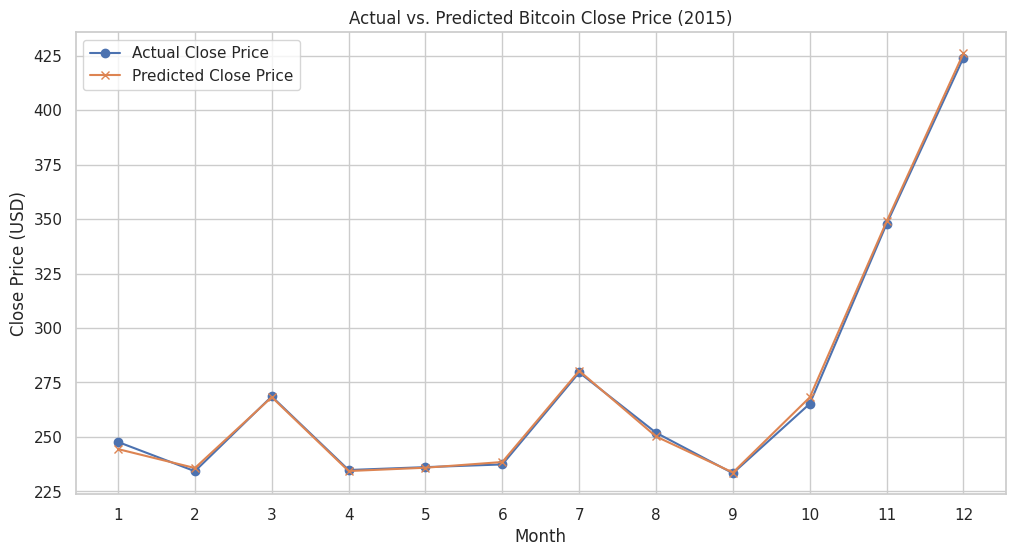

In [37]:
# Filter data for 2015
df_2015 = df[df['date'].dt.year == 2015]

# Group by month and get the mean of the actual and predicted close prices
monthly_actual = df_2015.groupby(df_2015['date'].dt.month)['close'].mean()

# Assuming you have a way to predict the close prices for 2015 (replace with your prediction method)
# For this example, I'll just use the previous day's close price as a simple prediction.
df_2015['predicted_close'] = df_2015['close'].shift(1)
monthly_predicted = df_2015.groupby(df_2015['date'].dt.month)['predicted_close'].mean()


# Create a plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_actual.index, monthly_actual.values, label='Actual Close Price', marker='o')
plt.plot(monthly_predicted.index, monthly_predicted.values, label='Predicted Close Price', marker='x')
plt.title('Actual vs. Predicted Bitcoin Close Price (2015)')
plt.xlabel('Month')
plt.ylabel('Close Price (USD)')
plt.xticks(monthly_actual.index)
plt.legend()
plt.grid(True)
plt.show()


/tmp/ipykernel_28583/1590446279.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2019_Q1['predicted_close'] = df_2019_Q1['close'].shift(1)


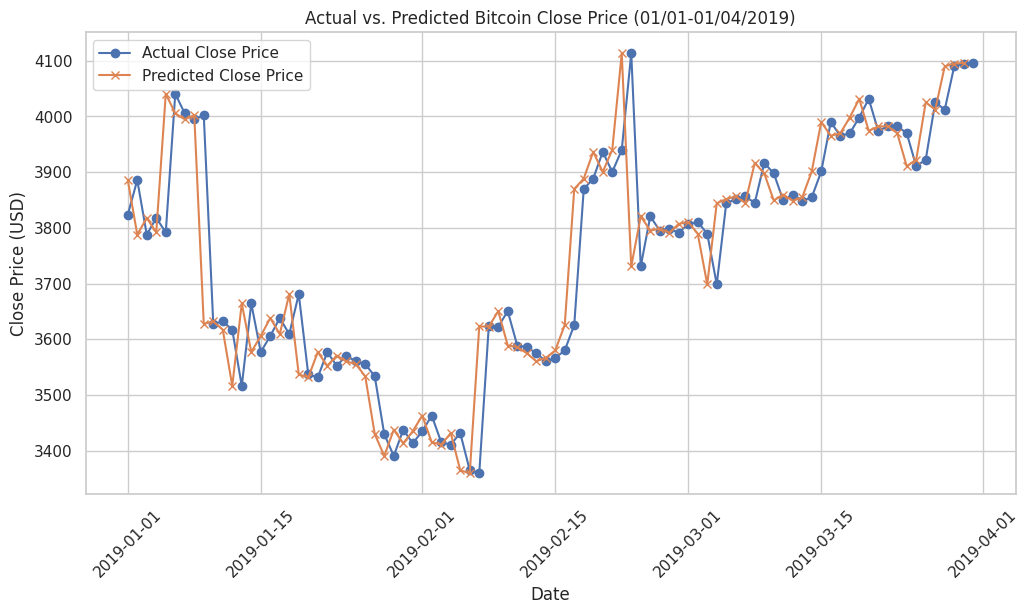

In [38]:
# Filter data for 2019-01-01 to 2019-03-31
df_2019_Q1 = df[(df['date'] >= '2019-01-01') & (df['date'] <= '2019-03-31')]

# Assuming you have a way to predict the close prices for 2019-01-01 to 2019-03-31 (replace with your prediction method)
# For this example, I'll just use the previous day's close price as a simple prediction.
df_2019_Q1['predicted_close'] = df_2019_Q1['close'].shift(1)

# Create a plot
plt.figure(figsize=(12, 6))
plt.plot(df_2019_Q1['date'], df_2019_Q1['close'], label='Actual Close Price', marker='o')
plt.plot(df_2019_Q1['date'], df_2019_Q1['predicted_close'], label='Predicted Close Price', marker='x')
plt.title('Actual vs. Predicted Bitcoin Close Price (01/01-01/04/2019)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()


# Sklearn and Kfold cross validation

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

In [41]:
# Normalize
scaler = StandardScaler()

df["Standardized_Date"] = scaler.fit_transform(df[["NumericalDate"]])
df["Standardized_Open_Prices"] = scaler.fit_transform(df[["open"]])
df["Standardized_High_Prices"] = scaler.fit_transform(df[["high"]])
df["Standardized_Low_Prices"] = scaler.fit_transform(df[["low"]])
df["Standardized_Close_Prices"] = scaler.fit_transform(df[["close"]])

In [42]:
X = df[["Standardized_Date", "Standardized_Open_Prices", "Standardized_High_Prices", "Standardized_Low_Prices"]].values
y = df["Standardized_Close_Prices"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, shuffle=True)

In [44]:
# K-FOLD and GRID SEARCH
model = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, random_state=42)

param_grid = {
    'learning_rate': ['constant'],
    'eta0': [0.1, 0.05, 0.01, 0.005, 0.001, 0.0001]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=kf,
    scoring='neg_mean_squared_error',
    return_train_score=True
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=SGDRegressor(penalty=None, random_state=42),
             param_grid={'eta0': [0.1, 0.05, 0.01, 0.005, 0.001, 0.0001],
                         'learning_rate': ['constant']},
             return_train_score=True, scoring='neg_mean_squared_error')

Best Learning Rate: 0.01
Test MSE is: 0.0007987005390619493


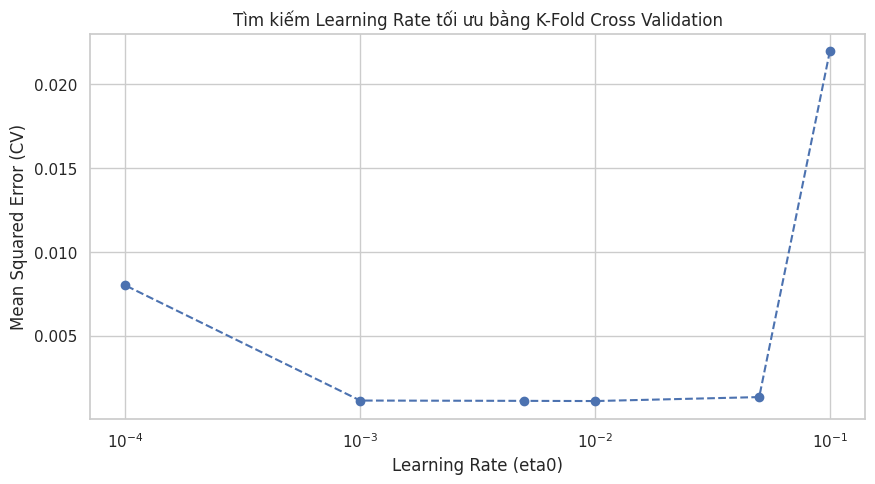

In [49]:
# Evaluation
best_lr = grid_search.best_params_['eta0']
print(f'Best Learning Rate: {best_lr}')

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE is: {test_mse}")

results = grid_search.cv_results_
lr_list = param_grid['eta0']
mean_test_scores = -results['mean_test_score'] # Chuyển lại về dạng MSE dương để vẽ đồ thị

plt.figure(figsize=(10, 5))
plt.plot(lr_list, mean_test_scores, marker='o', color='b', linestyle='--')
plt.xscale('log') # Dùng thang đo logarit cho trục X vì các giá trị lr chênh lệch cơ số 10
plt.xlabel('Learning Rate (eta0)')
plt.ylabel('Mean Squared Error (CV)')
plt.title('Tìm kiếm Learning Rate tối ưu bằng K-Fold Cross Validation')
plt.grid(True)
plt.show()